In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances

from sklearn.manifold import MDS, TSNE

In [ ]:
# Reproducible synthetic clustering data
X, y = make_blobs(
    n_samples=600,
    centers=4,
    n_features=10,          # higher-dim to make DR meaningful
    cluster_std=2.2,
    random_state=42
)

print("X shape:", X.shape, "y shape:", y.shape)
print("Unique labels:", np.unique(y))

X shape: (600, 10) y shape: (600,)
Unique labels: [0 1 2 3]


* X has shape (600, 10)—we cannot directly visualize 10D.
* We’ll use MDS and t-SNE to map 10D → 2D.
* This mimics real life: customer behavior vectors, embeddings, sensor features are often 10–1000 dimensions.
* We need 2D plots to “see” structure before modeling.

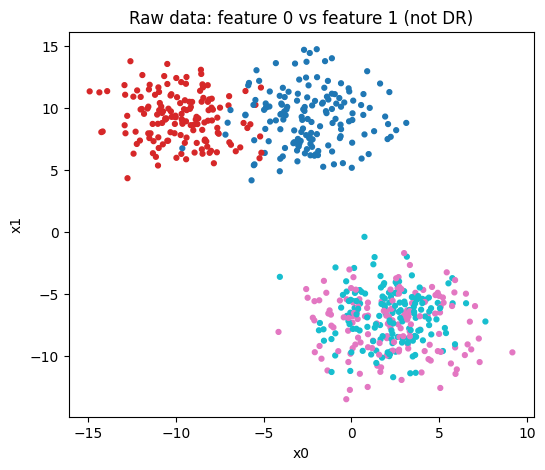

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=12, cmap="tab10")
plt.title("Raw data: feature 0 vs feature 1 (not DR)")
plt.xlabel("x0")
plt.ylabel("x1")
plt.show()

* Distance-based methods (MDS, t-SNE) are sensitive to scale:
* if one feature has large numeric range, it dominates distances

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled mean (approx):", X_scaled.mean(axis=0)[:3])
print("Scaled std  (approx):", X_scaled.std(axis=0)[:3])

Scaled mean (approx): [ 3.39358171e-16 -3.73775085e-17 -8.14163551e-18]
Scaled std  (approx): [1. 1. 1.]


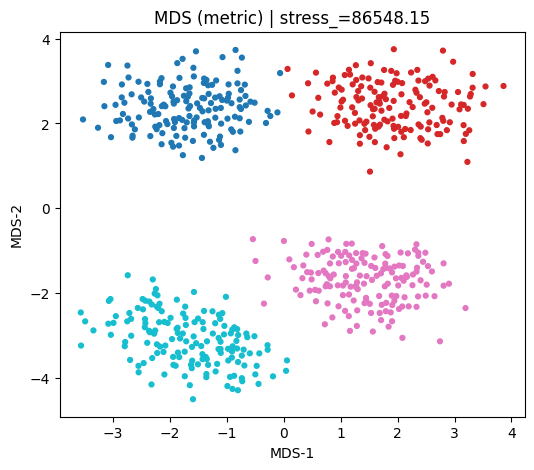

In [ ]:
mds = MDS(
    n_components=2,
    metric=True,
    n_init=4,
    max_iter=300,
    random_state=42,
    normalized_stress="auto"  # sklearn >= 1.2 typically
)

X_mds = mds.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_mds[:, 0], X_mds[:, 1], c=y, s=12, cmap="tab10")
plt.title(f"MDS (metric) | stress_={mds.stress_:.2f}")
plt.xlabel("MDS-1")
plt.ylabel("MDS-2")
plt.show()

# If your application cares about “how far” groups are, MDS is often more honest than t-SNE.

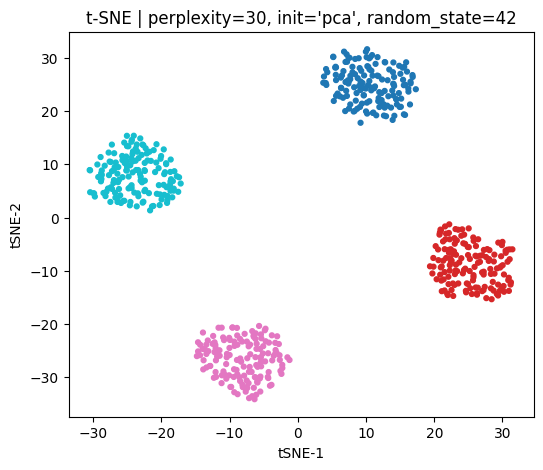

In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, s=12, cmap="tab10")
plt.title("t-SNE | perplexity=30, init='pca', random_state=42")
plt.xlabel("tSNE-1")
plt.ylabel("tSNE-2")
plt.show()

# t-SNE is excellent for:
* validating whether embeddings separate classes
exploring sub-clusters in high-dimensional representations (e.g., text/image embeddings)
* But: distances between far clusters are not reliable.

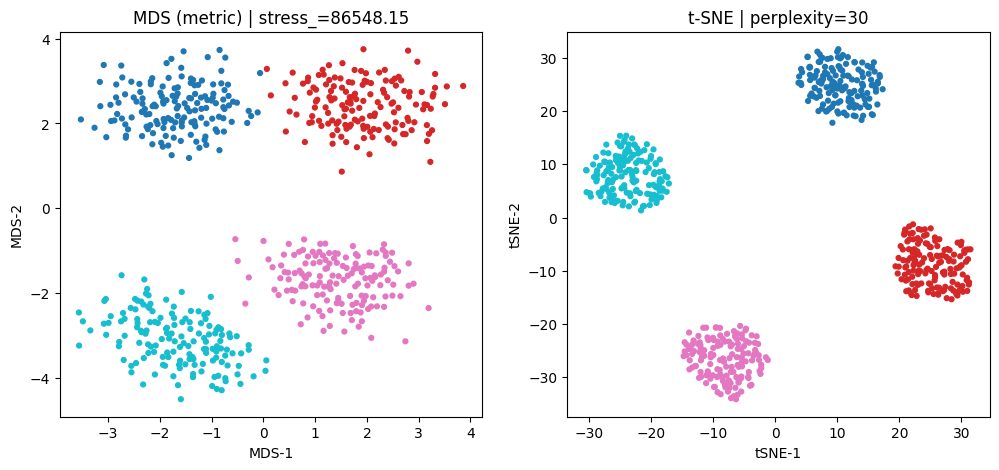

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(X_mds[:, 0], X_mds[:, 1], c=y, s=12, cmap="tab10")
ax[0].set_title(f"MDS (metric) | stress_={mds.stress_:.2f}")
ax[0].set_xlabel("MDS-1"); ax[0].set_ylabel("MDS-2")

ax[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, s=12, cmap="tab10")
ax[1].set_title("t-SNE | perplexity=30")
ax[1].set_xlabel("tSNE-1"); ax[1].set_ylabel("tSNE-2")

plt.show()

In [ ]:
from sklearn.metrics import pairwise_distances

D_high = pairwise_distances(X_scaled)
D_mds  = pairwise_distances(X_mds)
D_tsne = pairwise_distances(X_tsne)

# Correlation between all pairwise distances (flattened)
def dist_corr(A, B):
    a = A.ravel()
    b = B.ravel()
    return np.corrcoef(a, b)[0, 1]

print("Distance correlation (higher is more global-distance-faithful):")
print("  MDS  vs high-dim:", dist_corr(D_high, D_mds))
print("  t-SNE vs high-dim:", dist_corr(D_high, D_tsne))

Distance correlation (higher is more global-distance-faithful):
  MDS  vs high-dim: 0.9650574196100227
  t-SNE vs high-dim: 0.833609160130226


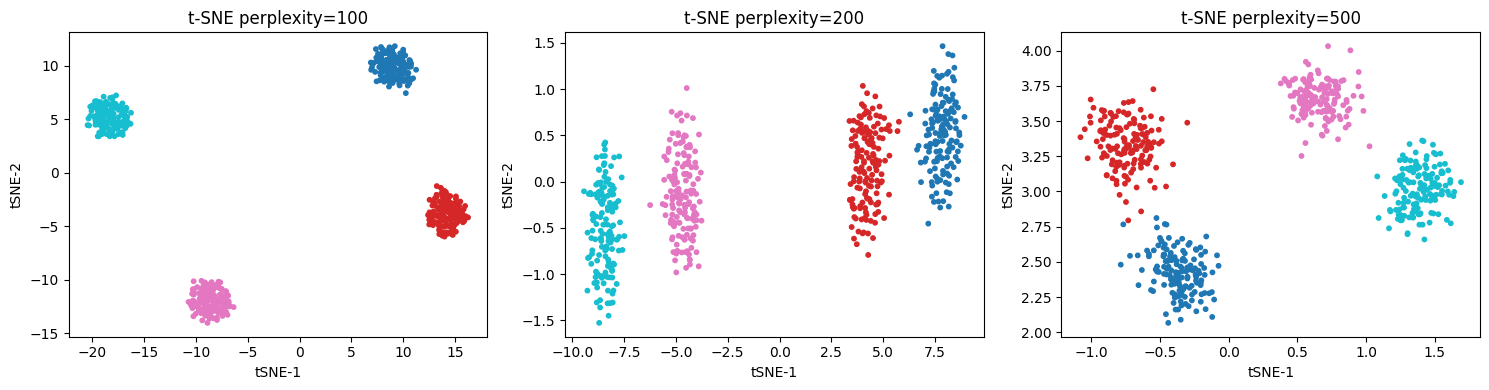

In [ ]:
perplexities = [100, 200, 500]

fig, axes = plt.subplots(1, len(perplexities), figsize=(15, 4), sharex=False, sharey=False)

for ax, p in zip(axes, perplexities):
    tsne = TSNE(
        n_components=2,
        perplexity=p,
        learning_rate="auto",
        init="pca",
        random_state=42
    )
    X_t = tsne.fit_transform(X_scaled)
    ax.scatter(X_t[:, 0], X_t[:, 1], c=y, s=10, cmap="tab10")
    ax.set_title(f"t-SNE perplexity={p}")
    ax.set_xlabel("tSNE-1"); ax.set_ylabel("tSNE-2")

plt.tight_layout()
plt.show()

# In industry, you typically run multiple seeds to confirm stability.

In [ ]:
seeds = [0, 1, 2]

fig, axes = plt.subplots(1, len(seeds), figsize=(15, 4))

for ax, seed in zip(axes, seeds):
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        early_exaggeration = 12.0,
        random_state=seed
    )
    X_t = tsne.fit_transform(X_scaled)
    ax.scatter(X_t[:, 0], X_t[:, 1], c=y, s=10, cmap="tab10")
    ax.set_title(f"t-SNE random_state={seed}")
    ax.set_xlabel("tSNE-1"); ax.set_ylabel("tSNE-2")

plt.tight_layout()
plt.show()

* n_init = number of random initializations (restarts). More restarts can find a better solution.
* stress_ can change; typically lower stress is better.

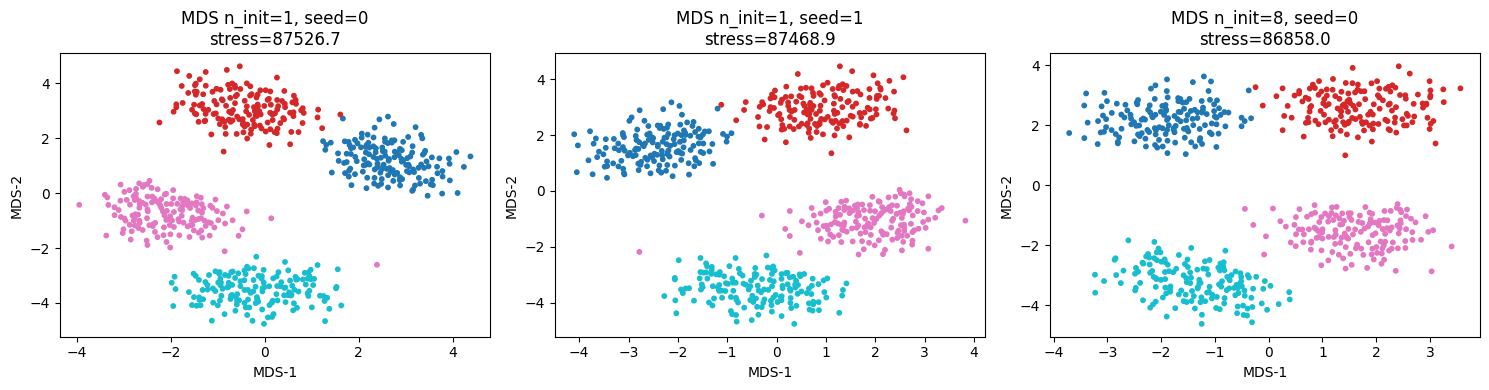

In [ ]:
settings = [
    {"n_init": 1, "random_state": 0},
    {"n_init": 1, "random_state": 1},
    {"n_init": 8, "random_state": 0},
]

fig, axes = plt.subplots(1, len(settings), figsize=(15, 4))

for ax, s in zip(axes, settings):
    mds = MDS(
        n_components=2,
        n_init=s["n_init"],
        max_iter=300,
        random_state=s["random_state"],
        normalized_stress="auto"
    )
    X_m = mds.fit_transform(X_scaled)
    ax.scatter(X_m[:, 0], X_m[:, 1], c=y, s=10, cmap="tab10")
    ax.set_title(f"MDS n_init={s['n_init']}, seed={s['random_state']}\nstress={mds.stress_:.1f}")
    ax.set_xlabel("MDS-1"); ax.set_ylabel("MDS-2")

plt.tight_layout()
plt.show()